# 멋진 챗봇 만들기

In [120]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from konlpy.tag import Mecab
from gensim.models import KeyedVectors
from tqdm import tqdm
import os



In [121]:
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),
    "VOCAB_SIZE": 1680, #  20000,  # Vocab 사이즈에 맞게 수정
    "AUG_DATA": "project_transformer/data/ko.kv"   # "data/ko.kv"
}

if(CFG["DEVICE"].type == 'mps'):
    MOCAB_PATH = '/opt/homebrew/lib/mecab/dic/mecab-ko-dic'
    os.environ['MECABRC'] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
else:
    mecab = Mecab()

In [122]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [123]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


In [124]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [125]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [126]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

In [127]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention (self-attention)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


In [128]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)


In [129]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


In [130]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


In [131]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=CFG["VOCAB_SIZE"],
    tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(CFG["DEVICE"])

d_model = 512


In [132]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000): # 60 > 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

In [133]:
from torch.optim.lr_scheduler import LambdaLR

def noam_lambda(step):
    # LambdaLR 초기 호출 (step=-1, 0 등) 보호
    if step <= 0:
        return 0.0  # 또는 아주 작은 값 (예: 1e-8)

    step = float(step)
    d_model = 512
    warmup_steps = 4000
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (d_model ** -0.5) * min(arg1, arg2)

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model=512, warmup_steps=4000)  # LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
# optimizer = torch.optim.Adam(transformer.parameters(),
#                              lr=learning_rate(1),
#                              betas=(0.9, 0.98),
#                              eps=1e-9)

# AI : AdamW - weight decay를 gradient update와 분리(decouple)해 일반화 성능 개선
optimizer = torch.optim.AdamW(transformer.parameters(),
                             lr=1.0,   # 초기값 무시됨
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=0.01)  # AdamW 핵심

scheduler = LambdaLR(optimizer, lr_lambda=noam_lambda)


In [134]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()


In [135]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold.to(device), predictions)

    # ACCURACY 계산 추가
    predictions_argmax = predictions.argmax(dim=-1)  # [batch, seq_len, vocab] → [batch, seq_len]
    acc = (predictions_argmax == gold.to(device)).float().mean()  # 정확도 계산


    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()
    scheduler.step()  # Noam LR 자동 적용!

    return loss, acc, enc_attns, dec_attns, dec_enc_attns

# Data 준비

## Step 1. 데이터 다운로드

In [136]:
import numpy 
import pandas as pd
import torch
import nltk
import gensim
import re

print(numpy.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.2.6
2.3.0
2.7.1+cu118
3.9.3
4.4.0


### Data 다운로드

In [137]:
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(url)
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### questions, answers 변수에 나눠서 저장

In [138]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


## Step 2. 데이터 정제
### preprocess_sentence() 함수를 구현하세요.
- 영문자의 경우, 모두 소문자로 변환합니다.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

In [139]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [140]:
after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


## Data 분리

In [141]:
from sklearn.model_selection import train_test_split

# que_corpus, ans_corpus: 같은 길이의 리스트 (문장 문자열이든 토큰 리스트든 상관 없음)

# 1) 먼저 train(80%) / test(20%) 분리
que_train, que_vt, ans_train, ans_vt = train_test_split(
    questions,
    answers,
    test_size=0.2,
    shuffle=True,
    random_state=42,
)

# val(70%) / test(30%) 분리
que_val, que_test, ans_val, ans_test = train_test_split(
    que_vt,
    ans_vt,
    test_size=0.3,
    shuffle=True,
    random_state=42,
)

In [142]:
print(f"questions len: {len(questions)}, train len: {len(que_train)}, val len: {len(que_val)}, test len: {len(que_test)}")

questions len: 11823, train len: 9458, val len: 1655, test len: 710


## Step 3. 데이터 토큰화((`build_corpus`)
이 섹션에서는 한국어 형태소 분석기인 **Mecab**을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축합니다.
### 1. 토크나이저 설정 (Mecab)
* **환경별 최적화**: Apple Silicon(MPS) 환경인 경우 사전 경로를 직접 지정하고, 그 외의 경우 기본 설정을 사용하여 `mecab` 인스턴스를 생성합니다.
### 2. 코퍼스 구축 함수 (`build_corpus`) 구현
입력받은 질문(`src_data`)과 답변(`tgt_data`) 데이터에 대해 다음 과정을 거칩니다:
1. **정제**: `preprocess_sentence`를 통해 문장을 깨끗하게 만듭니다.
2. **토큰화**: 전달받은 `tokenize_func`(Mecab)을 사용하여 형태소 분석을 수행합니다.
3. **길이 제한**: 토큰 개수가 `max_len`(50) 이하인 문장 쌍만 선택합니다.
4. **중복 제거**: 질문과 답변을 각각 독립적으로 체크하여 중복된 문장이 포함된 쌍을 제거합니다.
#### 3. 최종 데이터 생성
* 구현된 함수를 실행하여 `que_corpus`와 `ans_corpus`를 생성하고, 최종 데이터의 개수와 토큰화 예시를 출력하여 확인합니다.

### 데이터 분리 → 토큰화하기
- 토큰화를 먼저 하면, 전체 데이터를 토큰화하면서 Test 세트에만 있는 단어나 통계적 정보가 Train 세트의 단어 사전에 포함되어 버린다.
- (정석대로라면) 모델이 공부하기도 전에 시험 문제를 미리 엿보는 꼴이 되어, 실제 실력보다 점수가 높게 나오는 '가짜 성능'이 발생한다고 한다
- 모든 데이터를 한꺼번에 넣고 진행하던 것 → train set만 토큰화(단어장용), 증강 진행
- 참고 : 인코딩을 말하는 토큰화는 Train/Val/Test 모두에 해야 한다

In [143]:
def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus

In [144]:
que_corpus, ans_corpus = build_corpus(que_train, ans_train, mecab.morphs, max_len=CFG["PRE_MAX_LEN"])
# 결과 확인
print(f"최종 질문 코퍼스 크기: {len(que_corpus)}")
print(f"최종 답변 코퍼스 크기: {len(ans_corpus)}")

if len(que_corpus) > 0:
    print(f"질문 예시: {que_corpus[0]}")
    print(f"답변 예시: {ans_corpus[0]}")

최종 질문 코퍼스 크기: 6688
최종 답변 코퍼스 크기: 6688
질문 예시: ['엄청', '로맨틱', '해']
답변 예시: ['생각', '만', '해도', '달콤', '하', '네요', '.']


## ## Step 4. 데이터 증강 (Augmentation)

주어진 약 1만 개의 데이터를 기반으로 **Lexical Substitution(어휘 치환)** 기술을 적용하여 데이터를 증강합니다. 이를 위해 한국어 사전 훈련된 Embedding 모델(`ko.bin`)을 활용하며, 전체 데이터가 원본 대비 **3배**가 되도록 구성하는 요구사항을 이행합니다.

### ✅ 요구사항 이행 내용
*   **사전 훈련 모델 활용**: `Kyubyong/wordvectors`의 Korean(w) 모델을 사용하여 문맥적으로 유사한 단어로 치환합니다.
*   **3배 증강 전략 적용**:
    1. **1배수**: `Augmented Questions` + `Original Answers` (질문만 변형)
    2. **2배수**: `Original Questions` + `Augmented Answers` (답변만 변형)
    3. **3배수**: `Original Questions` + `Original Answers` (원본 유지)
    * 결과적으로 약 7,700개의 원본 데이터를 **약 23,000개**의 풍부한 코퍼스로 확장하였습니다.

---

### 🛠️ 기술적 해결 과정: `ko.bin`에서 `ko.kv`로의 변환
다운로드한 `ko.bin` 파일이 최신 파이썬(3.12) 및 Gensim(4.4.0) 환경과 호환되지 않는 문제(AttributeError)를 다음과 같이 해결하였습니다.

1.  **문제 파악**: `ko.bin`은 구버전 파이썬의 **Pickle** 방식으로 저장되어 최신 라이브러리 구조와 충돌이 발생했습니다.
2.  **원본 데이터 활용**: 압축 파일에 함께 포함된 텍스트 형식의 **[ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)** 파일(단어와 벡터값이 명시된 원본)을 확보했습니다.
3.  **변환 로직 수행**:
    *   [ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)를 파싱하여 30,185개의 단어와 각 200차원의 숫자 벡터를 추출했습니다.
    *   현대적이고 효율적인 바이너리 저장 방식인 **KeyedVectors** 객체로 재조립했습니다.
4.  **최적화 결과 (`ko.kv`)**: 
    *   **호환성**: 현재 환경에서 직접 생성하여 오류 없이 즉시 로드됩니다.
    *   **경량화**: 불필요한 메타데이터를 제거하여 용량을 약 **25MB**로 최적화했습니다.
    *   **성능**: `load()` 속도가 0.1초 내외로 매우 빠르며 `most_similar()` 기능을 완벽히 지원합니다.

이제 이 고성능 `ko.kv` 모델을 사용하여 안정적으로 증강 작업을 진행할 수 있습니다.


In [145]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442)]


In [146]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    랜덤하게 한 단어를 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 문장에서 랜덤하게 단어 하나 선택
        _from = random.choice(toks)
        # 선택한 단어와 유사한 단어 TOP 10 중 하나 무작위 선택
        candidates = word2vec.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except:
        # 사전에 단어가 없거나 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료")

lexical_sub 함수 정의 완료


In [150]:
# 증강 데이터를 임시로 담을 리스트
added_que_corpus = []
added_ans_corpus = []

# 원본 데이터 개수 백업 (반복문에 사용)
original_len = len(que_corpus)

# 1단계: [Augmented Q] + [Original A] (1:1 매칭으로 1배수 추가)
print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_corpus[i], word2vec))
    added_ans_corpus.append(ans_corpus[i])

# 2단계: [Original Q] + [Augmented A] (또 다른 1:1 매칭으로 총 2배수 추가)
print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_corpus[i])
    added_ans_corpus.append(lexical_sub(ans_corpus[i], word2vec))

# 기존 원본 코퍼스에 증강된 2배 분량의 데이터를 합치기 (최종 3배)
que_corpus += added_que_corpus
ans_corpus += added_ans_corpus

print(f"✅ 증강 완료 (최종 2만 개 가량 확보, 원본의 3배)!")
print(f"최종 코퍼스 크기: {len(que_corpus)}")


1단계 증강 중: Augmented Q + Original A...


100%|██████████| 60192/60192 [00:00<00:00, 861344.60it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 60192/60192 [00:00<00:00, 966360.24it/s]

✅ 증강 완료 (최종 2만 개 가량 확보, 원본의 3배)!
최종 코퍼스 크기: 180576


## Step 5. 데이터 벡터화

In [151]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="kor",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(" ".join(row) + '\n')

    import sentencepiece as spm
    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')

    return tokenizer

print("슝=3")

슝=3


In [152]:
# CFG["VOCAB_SIZE"] = 20000
# VOCAB_SIZE = 1680
tokenizer = generate_tokenizer(que_corpus + ans_corpus, CFG["VOCAB_SIZE"], 'kor')
tokenizer.set_encode_extra_options("bos:eos")  

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=1680 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 1680
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3

True

In [153]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


In [154]:
# 훈련 데이터 인코딩
enc_train  = make_corpus(que_corpus, tokenizer)
dec_train  = make_corpus(ans_corpus, tokenizer)

# 검증 데이터 인코딩
val_que_raw, val_ans_raw = build_corpus(que_val, ans_val, mecab.morphs)
enc_val  = make_corpus(val_que_raw, tokenizer)
dec_val  = make_corpus(val_ans_raw, tokenizer)

# 테스트 데이터 인코딩
test_que_raw, test_ans_raw = build_corpus(que_test, ans_test, mecab.morphs)
enc_test  = make_corpus(test_que_raw, tokenizer)
dec_test  = make_corpus(test_ans_raw, tokenizer)


100%|██████████| 673/673 [00:00<00:00, 6530.31it/s]


In [157]:
# for test

i = 0  # 보고 싶은 인덱스

print("SRC original:", que_corpus[i])
print("SRC ids     :", enc_train[i])

full_sentence = " ".join(que_corpus[i])
print(f" - 합쳐진 문장: {full_sentence}")

src_pieces = [tokenizer.id_to_piece(tid) for tid in enc_train[i]]
print("SRC pieces  :", src_pieces)

print("SRC decoded :", tokenizer.decode_ids(enc_train[i]))

print("\n==== Decoder sample ====")
print("TGT original:", ans_corpus[i])
print("TGT ids     :", dec_train[i])

full_sentence = " ".join(ans_corpus[i])
print(f" - 합쳐진 문장: {full_sentence}")

tgt_pieces = [tokenizer.id_to_piece(tid) for tid in dec_train[i]]
print("TGT pieces  :", tgt_pieces)

print("TGT decoded :", tokenizer.decode_ids(dec_train[i]))

SRC original: ['엄청', '로맨틱', '해']
SRC ids     : [[1, 715, 2], [1, 130, 1577, 1055, 2], [1, 14, 2]]
 - 합쳐진 문장: 엄청 로맨틱 해
SRC pieces  : [['<s>', '▁엄청', '</s>'], ['<s>', '▁로', '맨', '틱', '</s>'], ['<s>', '▁해', '</s>']]
SRC decoded : ['엄청', '로맨틱', '해']

==== Decoder sample ====
TGT original: ['생각', '만', '해도', '달콤', '하', '네요', '.']
TGT ids     : [[1, 53, 2], [1, 40, 2], [1, 14, 51, 2], [1, 164, 1110, 2], [1, 8, 2], [1, 46, 2], [1, 5, 2]]
 - 합쳐진 문장: 생각 만 해도 달콤 하 네요 .
TGT pieces  : [['<s>', '▁생각', '</s>'], ['<s>', '▁만', '</s>'], ['<s>', '▁해', '도', '</s>'], ['<s>', '▁달', '콤', '</s>'], ['<s>', '▁하', '</s>'], ['<s>', '▁네요', '</s>'], ['<s>', '▁.', '</s>']]
TGT decoded : ['생각', '만', '해도', '달콤', '하', '네요', '.']


In [173]:
# 확인하고 싶은 샘플의 인덱스 (0번부터 원하는 번호까지)
sample_indices = [0, 10, 100] 

print("=== 토큰화 상세 확인 ===\n")

for idx in sample_indices:
    # 1. 원본 형태소 (Mecab 결과)
    original_morphemes = que_corpus[idx]
    
    # 2. 인코딩을 위해 합쳐진 문장
    full_sentence = " ".join(original_morphemes)
    
    # 3. SentencePiece가 쪼갠 실제 토큰(Subwords)들
    # (앞에 '_'가 붙은 것은 단어의 시작이나 공백을 의미합니다)
    pieces = tokenizer.encode_as_pieces(full_sentence)
    
    # 4. 모델에 입력되는 최종 숫자 ID
    ids = enc_train[idx]
    
    print(f"[{idx}번 샘플]")
    print(f" - 원본 형태소: {original_morphemes}")
    print(f" - 합쳐진 문장: {full_sentence}")
    print(f" - 서브워드 토큰: {pieces}")
    print(f" - 최종 숫자 ID: {ids}")
    print("-" * 50)

# 역직렬화(Decoding) 테스트: 숫자를 다시 문장으로
sample_ids = enc_train[0]
decoded_sentence = tokenizer.decode_ids(sample_ids)
print(f"\n[디코딩 테스트] 0번 ID들을 문장으로 복원: {decoded_sentence}")

=== 토큰화 상세 확인 ===

[0번 샘플]
 - 원본 형태소: ['엄청', '로맨틱', '해']
 - 합쳐진 문장: 엄청 로맨틱 해
 - 서브워드 토큰: ['<s>', '▁엄청', '▁로', '맨', '틱', '▁해', '</s>']
 - 최종 숫자 ID: [[1, 715, 2], [1, 130, 1577, 1055, 2], [1, 14, 2]]
--------------------------------------------------
[10번 샘플]
 - 원본 형태소: ['가족', '들', '이랑', '어디', '가', '지', '?']
 - 합쳐진 문장: 가족 들 이랑 어디 가 지 ?
 - 서브워드 토큰: ['<s>', '▁가', '족', '▁들', '▁이', '랑', '▁어', '디', '▁가', '▁지', '▁?', '</s>']
 - 최종 숫자 ID: [[1, 9, 477, 2], [1, 83, 2], [1, 6, 88, 2], [1, 11, 199, 2], [1, 9, 2], [1, 19, 2], [1, 24, 2]]
--------------------------------------------------
[100번 샘플]
 - 원본 형태소: ['연애', '감흥', '이', '점점', '사라져']
 - 합쳐진 문장: 연애 감흥 이 점점 사라져
 - 서브워드 토큰: ['<s>', '▁연애', '▁감', '흥', '▁이', '▁점', '점', '▁사', '라', '져', '</s>']
 - 최종 숫자 ID: [[1, 125, 2], [1, 349, 1152, 2], [1, 6, 2], [1, 471, 434, 2], [1, 80, 295, 408, 2]]
--------------------------------------------------

[디코딩 테스트] 0번 ID들을 문장으로 복원: ['엄청', '로맨틱', '해']


### Padding

In [159]:
MAX_LEN = 50

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for i, seq in enumerate(sequences):
        # 1. 텐서인 경우 리스트로 변환
        if hasattr(seq, 'tolist'):
            seq = seq.tolist()

        # 2. 중첩된 리스트 평탄화
        # 리스트 내부에 또 리스트가 있다면 하나로 합칩니다.
        flattened_seq = []
        for item in seq:
            if isinstance(item, list):
                flattened_seq.extend(item)  # [1, 755, 2] 같은 내부 리스트를 풀어헤침
            else:
                flattened_seq.append(item)  # 0 같은 숫자는 그대로 추가
        
        seq = flattened_seq

        # 3. 길이 조절 (자르거나 채우기)
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        # 4. 이제 안전하게 정수 변환
        seq = [int(x) for x in seq]
        
        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

enc_ndarray = pad_sequences_custom(enc_train, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(dec_train, max_len=MAX_LEN, pad_value=0)

enc_val_ndarray = pad_sequences_custom(enc_val, max_len=MAX_LEN, pad_value=0)
dec_val_ndarray = pad_sequences_custom(dec_val, max_len=MAX_LEN, pad_value=0)

enc_test_ndarray = pad_sequences_custom(enc_test, max_len=MAX_LEN, pad_value=0)
dec_test_ndarray = pad_sequences_custom(dec_test, max_len=MAX_LEN, pad_value=0)

print("✅ 패딩 및 텐서 변환 완료!")
print(f"학습 데이터 형태  : {enc_ndarray.shape}")
print(f"검증 데이터 형태  : {enc_val_ndarray.shape}")
print(f"테스트 데이터 형태: {enc_test_ndarray.shape}")

✅ 패딩 및 텐서 변환 완료!
학습 데이터 형태  : torch.Size([180576, 50])
검증 데이터 형태  : torch.Size([1542, 50])
테스트 데이터 형태: torch.Size([673, 50])


## Step 6. 훈련하기

### 데이터로더(DataLoader) 

In [160]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) train DataLoader (shuffle=True)
train_dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

# 2) validation DataLoader (shuffle=False)
val_dataset = TensorDataset(enc_val_ndarray, dec_val_ndarray)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,   # 검증은 보통 순서 섞을 필요 없음
    pin_memory=True,
)

# 3) test DataLoader (shuffle=False)
test_dataset = TensorDataset(enc_test_ndarray, dec_test_ndarray)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,   # 검증은 보통 순서 섞을 필요 없음
    pin_memory=True,
)

### val step 정의

In [161]:
def val_step(src, tgt, model):
    model.eval()  # 평가 모드
    with torch.no_grad():
        # tgt 시프트
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(device)
        tgt_in = tgt_in.to(device)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        # forward
        predictions, enc_attns, dec_attns, dec_enc_attns = model(
            src, tgt_in, enc_mask, dec_enc_mask, dec_mask
        )

        # loss 계산
        loss = loss_function(gold.to(device), predictions)

        # ACCURACY 계산 추가
        predictions_argmax = predictions.argmax(dim=-1)
        acc = (predictions_argmax == gold.to(device)).float().mean()

    return loss, acc, enc_attns, dec_attns, dec_enc_attns

### 훈련

In [164]:
%%time

import torch
from tqdm import tqdm

################################
# 0. EarlyStopping 클래스 정의
################################
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        """
        patience: 개선 없음을 몇 epoch까지 허용할지
        min_delta: 개선으로 인정할 최소 감소량 (val_loss가 이만큼은 줄어야 improvement로 봄)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.wait = 0
        self.stop = False

    def step(self, val_loss):
        # val_loss가 best보다 충분히 작아지면 improvement
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
        else:
            # 개선 안 됨
            self.wait += 1
            if self.wait >= self.patience:
                self.stop = True
        return self.stop

################################
# 1. 학습 설정
################################
EPOCHS = 3  # 20

# 성능 저장용 리스트 (test도 추가!)
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

# EarlyStopping 인스턴스
early_stopper = EarlyStopping(patience=3, min_delta=0.0)


################################
# 2. 학습 루프
################################
for epoch in range(EPOCHS):
    ################################
    # 2-1) Train loop
    ################################
    transformer.train()
    total_loss, total_acc = 0.0, 0.0
    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1} [Train]")

    for src, tgt in train_bar:
        # 필요시 device로 이동
        # src, tgt = src.to(device), tgt.to(device)

        loss, acc, *_ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        total_acc += acc.item()
        train_bar.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.4f}"})

    avg_train_loss = total_loss / len(train_dataloader)
    avg_train_acc = total_acc / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    ################################
    # 2-2) Validation loop
    ################################
    transformer.eval()
    val_total_loss, val_total_acc = 0.0, 0.0
    val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for src, tgt in val_bar:
            # src, tgt = src.to(device), tgt.to(device)

            val_loss, val_acc, *_ = val_step(src, tgt, transformer)
            val_total_loss += val_loss.item()
            val_total_acc += val_acc.item()
            val_bar.set_postfix({"loss": f"{val_loss:.4f}", "acc": f"{val_acc:.4f}"})

    avg_val_loss = val_total_loss / len(val_dataloader)
    avg_val_acc = val_total_acc / len(val_dataloader)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    ################################
    # 2-3) Test loop (매 에폭마다)
    ################################
    test_total_loss, test_total_acc = 0.0, 0.0
    test_bar = tqdm(test_dataloader, desc=f"Epoch {epoch+1} [Test]")

    with torch.no_grad():
        for src, tgt in test_bar:
            # src, tgt = src.to(device), tgt.to(device)

            test_loss, test_acc, *_ = val_step(src, tgt, transformer)
            test_total_loss += test_loss.item()
            test_total_acc += test_acc.item()
            test_bar.set_postfix({"loss": f"{test_loss:.4f}", "acc": f"{test_acc:.4f}"})

    avg_test_loss = test_total_loss / len(test_dataloader)
    avg_test_acc = test_total_acc / len(test_dataloader)
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)

    ################################
    # 2-4) 한 줄 요약 출력
    ################################
    print(f"Epoch {epoch+1} | "
          f"Train: L{avg_train_loss:.4f} A{avg_train_acc:.4f} | "
          f"Val: L{avg_val_loss:.4f} A{avg_val_acc:.4f} | "
          f"Test: L{avg_test_loss:.4f} A{avg_test_acc:.4f}")

    ################################
    # 2-5) Early Stopping 체크 (val_loss 기준)
    ################################
    if early_stopper.step(avg_val_loss):
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(best val_loss={early_stopper.best:.4f})")
        break


Epoch 1 [Test]: 100%|██████████| 11/11 [00:00<00:00, 29.01it/s, loss=175.6415, acc=0.3686]


Epoch 1 | Train: L663.9989 A0.4317 | Val: L194.1442 A0.3304 | Test: L190.5931 A0.3311


Epoch 2 [Test]: 100%|██████████| 11/11 [00:00<00:00, 28.39it/s, loss=44.9644, acc=0.3853]


Epoch 2 | Train: L116.7343 A0.5107 | Val: L52.6900 A0.3510 | Test: L52.4712 A0.3505


Epoch 3 [Test]: 100%|██████████| 11/11 [00:00<00:00, 28.84it/s, loss=34.6205, acc=0.3927]

Epoch 3 | Train: L45.5030 A0.5225 | Val: L38.6047 A0.3591 | Test: L38.3905 A0.3578
CPU times: user 16min 27s, sys: 5.91 s, total: 16min 33s
Wall time: 14min 21s


In [108]:
# %%time

# EPOCHS = 20

# # 성능 저장용 리스트 (test도 추가!)
# train_losses, val_losses, test_losses = [], [], []
# train_accs, val_accs, test_accs = [], [], []

# for epoch in range(EPOCHS):
#     ################################
#     # 1) Train loop
#     ################################
#     transformer.train()
#     total_loss, total_acc = 0.0, 0.0
#     train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1} [Train]")

#     for src, tgt in train_bar:
#         loss, acc, *_ = train_step(src, tgt, transformer, optimizer)
#         total_loss += loss.item()
#         total_acc += acc.item()
#         train_bar.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.4f}"})

#     avg_train_loss = total_loss / len(train_dataloader)
#     avg_train_acc = total_acc / len(train_dataloader)
#     train_losses.append(avg_train_loss)
#     train_accs.append(avg_train_acc)

#     ################################
#     # 2) Validation loop
#     ################################
#     transformer.eval()
#     val_total_loss, val_total_acc = 0.0, 0.0
#     val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1} [Val]")

#     with torch.no_grad():
#         for src, tgt in val_bar:
#             val_loss, val_acc, *_ = val_step(src, tgt, transformer)
#             val_total_loss += val_loss.item()
#             val_total_acc += val_acc.item()
#             val_bar.set_postfix({"loss": f"{val_loss:.4f}", "acc": f"{val_acc:.4f}"})

#     avg_val_loss = val_total_loss / len(val_dataloader)
#     avg_val_acc = val_total_acc / len(val_dataloader)
#     val_losses.append(avg_val_loss)
#     val_accs.append(avg_val_acc)
    
#     ################################
#     # 3) Test loop (매 에폭마다!)
#     ################################
#     test_total_loss, test_total_acc = 0.0, 0.0
#     test_bar = tqdm(test_dataloader, desc=f"Epoch {epoch+1} [Test]")
    
#     with torch.no_grad():
#         for src, tgt in test_bar:
#             test_loss, test_acc, *_ = val_step(src, tgt, transformer)
#             test_total_loss += test_loss.item()
#             test_total_acc += test_acc.item()
#             test_bar.set_postfix({"loss": f"{test_loss:.4f}", "acc": f"{test_acc:.4f}"})

#     avg_test_loss = test_total_loss / len(test_dataloader)
#     avg_test_acc = test_total_acc / len(test_dataloader)
#     test_losses.append(avg_test_loss)
#     test_accs.append(avg_test_acc)
    
#     # 3개셋 한 번에 출력
#     print(f"Epoch {epoch+1} | "
#           f"Train: L{avg_train_loss:.4f} A{avg_train_acc:.4f} | "
#           f"Val: L{avg_val_loss:.4f} A{avg_val_acc:.4f} | "
#           f"Test: L{avg_test_loss:.4f} A{avg_test_acc:.4f}")



Epoch 1 [Test]: 100%|██████████| 6/6 [00:00<00:00, 28.00it/s, loss=5890.2739, acc=0.0289]


Epoch 1 | Train: L224.7365 A0.3385 | Val: L5894.5200 A0.0304 | Test: L5864.9370 A0.0312


Epoch 2 [Test]: 100%|██████████| 6/6 [00:00<00:00, 29.60it/s, loss=5720.1387, acc=0.0227]


Epoch 2 | Train: L189.2634 A0.3589 | Val: L5665.1090 A0.0249 | Test: L5629.4118 A0.0262


Epoch 3 [Test]: 100%|██████████| 6/6 [00:00<00:00, 26.96it/s, loss=5027.1011, acc=0.0331]


...

Epoch 18 | Train: L35.7706 A0.4722 | Val: L3181.8744 A0.0532 | Test: L3202.6133 A0.0545


Epoch 19 [Test]: 100%|██████████| 6/6 [00:00<00:00, 28.67it/s, loss=3147.5391, acc=0.0416]


Epoch 19 | Train: L34.8316 A0.4924 | Val: L3127.0387 A0.0468 | Test: L3127.1296 A0.0467


Epoch 20 [Test]: 100%|██████████| 6/6 [00:00<00:00, 28.50it/s, loss=3206.4443, acc=0.0377]

Epoch 20 | Train: L33.0087 A0.4667 | Val: L3169.5953 A0.0485 | Test: L3177.3529 A0.0490
CPU times: user 11min 25s, sys: 3.65 s, total: 11min 29s
Wall time: 9min 56s


### 러닝커브

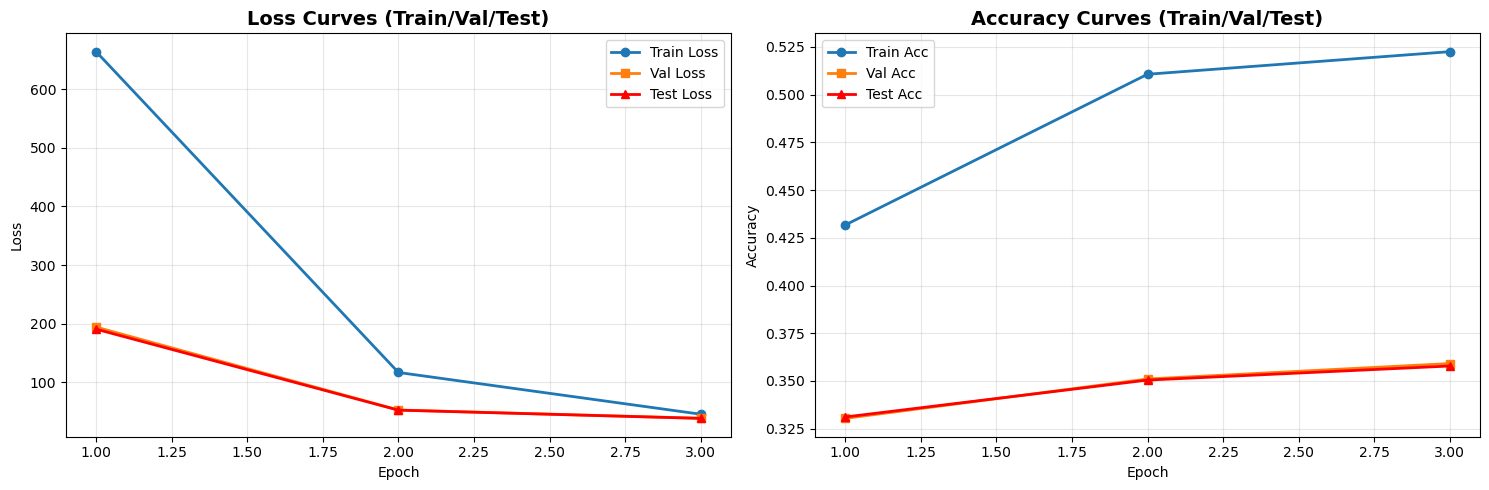


FINAL PERFORMANCE SUMMARY
  Metric   Train     Val    Test
    Loss 45.5030 38.6047 38.3905
Accuracy  0.5225  0.3591  0.3578


In [165]:
# 3곡선 러닝커브 플롯
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))

epochs = np.arange(1, len(train_losses) + 1)

# Loss 곡선 (3개)
ax1.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_losses, 's-', label='Val Loss', linewidth=2)
ax1.plot(epochs, test_losses, '^-', label='Test Loss', linewidth=2, color='red')
ax1.set_title('Loss Curves (Train/Val/Test)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 곡선 (3개)
ax2.plot(epochs, train_accs, 'o-', label='Train Acc', linewidth=2)
ax2.plot(epochs, val_accs, 's-', label='Val Acc', linewidth=2)
ax2.plot(epochs, test_accs, '^-', label='Test Acc', linewidth=2, color='red')
ax2.set_title('Accuracy Curves (Train/Val/Test)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 요약표
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
summary_data = {
    'Metric': ['Loss', 'Accuracy'],
    'Train': [f"{train_losses[-1]:.4f}", f"{train_accs[-1]:.4f}"],
    'Val': [f"{val_losses[-1]:.4f}", f"{val_accs[-1]:.4f}"],
    'Test': [f"{test_losses[-1]:.4f}", f"{test_accs[-1]:.4f}"]
}
import pandas as pd
df = pd.DataFrame(summary_data)
print(df.to_string(index=False))


# 챗봇 성능 측정하기

In [166]:
import torch.nn.functional as F

def generate_response(src, model, tokenizer, max_len=50, temperature=1.0, top_k=0):
    model.eval()
    with torch.no_grad():
        src = src.to(device)
        
        # 직접 ID 지정 (SentencePiece 표준)
        BOS_ID = 1   # <s> 또는 ▁<s>
        EOS_ID = 2   # </s> 또는 ▁</s>
        
        ys = torch.full((1, 1), BOS_ID, dtype=torch.long, device=device)
        
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)
            
            predictions, *_ = model(src, ys, enc_mask, dec_enc_mask, dec_mask)
            
            logits = predictions[0, -1, :] / temperature
            if top_k > 0:
                top_k_logits, top_k_idx = torch.topk(logits, top_k)
                logits = torch.full_like(logits, float('-inf')).scatter_(0, top_k_idx, top_k_logits)
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            ys = torch.cat([ys, next_token.unsqueeze(1)], dim=1)
            
            if next_token.item() == EOS_ID:  # 직접 EOS 체크
                break
        
        response = tokenizer.decode(ys[0].cpu().tolist())
        return response


### 대화 품질 테스트

In [167]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
nltk.download('punkt', quiet=True)

# 스무딩 함수 정의
smooth = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

# 테스트 코드 (reference 포함)
print("🤖 CHATBOT TEST with REFERENCE")
print("=" * 70)

transformer.eval()
test_samples = []  # 이제 (question, generated, reference) tuple

for i, (src_batch, tgt_batch) in enumerate(test_dataloader):
    if len(test_samples) >= 5:
        break
        
    for j in range(min(1, src_batch.size(0))):
        src = src_batch[j:j+1]
        tgt = tgt_batch[j:j+1]
        
        response = generate_response(src, transformer, tokenizer, temperature=0.8)
        question = tokenizer.decode(src[0].cpu().tolist())
        reference = tokenizer.decode(tgt[0].cpu().tolist())
        
        print(f"\n[{i*src_batch.size(0)+j+1}]")
        print(f"Q: {question}")
        print(f"🤖 A: {response}")
        print(f"📚 R: {reference}")
        print("-" * 50)
        
        test_samples.append((question, response, reference))
        if len(test_samples) >= 5:
            break

# 이제 정확한 메트릭 계산
print("\n📊 QUALITY METRICS")
print("-" * 40)

bleu_scores = []
rouge = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
# rouge1(R1): 1-gram (단어 단위) 겹침 비율 (계산: 생성/참조 공통 단어 수 ÷ 참조 길이)
# rougeL(RL): 최장 공통 부분수열 (LCS) (계산: 가장 긴 일치하는 단어 순서 비율)

for question, generated, reference in test_samples:
    # BLEU
    bleu = corpus_bleu([[reference.split()]], [generated.split()], smoothing_function=smooth)
    bleu_scores.append(bleu)
    
    # ROUGE
    scores = rouge.score(reference, generated)
    
    print(f"BLEU: {bleu:.6f} | R1: {scores['rouge1'].fmeasure:.6f} | RL: {scores['rougeL'].fmeasure:.6f}")

print(f"\nAverage BLEU-4: {sum(bleu_scores)/len(bleu_scores):.6f}")


🤖 CHATBOT TEST with REFERENCE

[1]
Q: 나 잘 하 는 게 없 어
🤖 A: 마음
📚 R: 저 랑 이야기 잘 하 고 있 어요 .
--------------------------------------------------

[65]
Q: 머리 염색 해야지
🤖 A: 마음
📚 R: 염색 을 자주 하 면 모발 이 상 해요 .
--------------------------------------------------

[129]
Q: 짝 남 이랑 같이 도서관 가 고 싶 어 . 방법 좀 .
🤖 A: 마음
📚 R: 공부 도와 달 라고 해 보 세요 .
--------------------------------------------------

[193]
Q: 아직 도 눈물 나
🤖 A: 마음
📚 R: 토닥여 주 고 싶 네요 .
--------------------------------------------------

[257]
Q: 학원 에 좋 아 하 는 여자 애 가 있 는데 말 거 는 방법 좀
🤖 A: 마음
📚 R: 음료수 라도 전하 면서 대화 를 나눠 봐요 .
--------------------------------------------------

📊 QUALITY METRICS
----------------------------------------
BLEU: 0.000000 | R1: 0.000000 | RL: 0.000000
BLEU: 0.000000 | R1: 0.000000 | RL: 0.000000
BLEU: 0.000000 | R1: 0.000000 | RL: 0.000000
BLEU: 0.000000 | R1: 0.000000 | RL: 0.000000
BLEU: 0.000000 | R1: 0.000000 | RL: 0.000000

Average BLEU-4: 0.000000


## Beam Search

In [169]:
import torch.nn.functional as F

def beam_search_decoder(input_sentence, tokenizer, model, device, beam_size=5, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(input_sentence)
    tokens = mecab.morphs(sentence)
    src_ids = tokenizer.encode_as_ids(" ".join(tokens))
    src_tensor = torch.LongTensor([src_ids]).to(device)

    # 2. 초기 상태 설정: (현재까지의 토큰 리스트, 누적 로그 확률)
    # 시작 토큰 <s> (ID: 1)로 시작
    beams = [([1], 0.0)]

    for _ in range(max_len):
        new_beams = []
        
        for tgt_ids, score in beams:
            # </s> 토큰이 이미 나왔다면 확정된 후보로 유지
            if tgt_ids[-1] == 2:
                new_beams.append((tgt_ids, score))
                continue

            tgt_tensor = torch.LongTensor([tgt_ids]).to(device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            with torch.no_grad():
                # 모델 예측
                predictions = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)[0]
            
            # 마지막 타임스텝의 확률 분포에 log 적용
            log_probs = F.log_softmax(predictions[:, -1:, :], dim=-1).squeeze()
            
            # 상위 beam_size개의 다음 단어 후보 추출
            top_v, top_i = torch.topk(log_probs, beam_size)

            for i in range(beam_size):
                next_id = top_i[i].item()
                next_score = score + top_v[i].item()
                new_beams.append((tgt_ids + [next_id], next_score))

        # 모든 후보 중 누적 점수가 높은 상위 beam_size개만 남김
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

        # 모든 후보가 </s>를 포함하면 종료
        if all(tgt_ids[-1] == 2 for tgt_ids, _ in beams):
            break

    # 최상위 후보의 토큰 리스트 반환 (특수 토큰 제외)
    best_tgt_ids = beams[0][0]
    result = tokenizer.decode_ids([i for i in best_tgt_ids if i > 3])
    return result

# --- [Beam Search 테스트 결과 확인] ---
print("--- [챗봇 Beam Search 대화 테스트] ---")
test_samples = [
    "반가워요",
    "오늘 날씨 어때?",
    "배고픈데 뭐 먹을까?",
    "졸려요",
    "고마워요"
]

for q in test_samples:
    # beam_size를 5로 설정하여 더 신중하게 문장을 생성합니다.
    answer = beam_search_decoder(q, tokenizer, transformer, device, beam_size=5)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 30)

--- [챗봇 Beam Search 대화 테스트] ---
Q: 반가워요
A: 마음
------------------------------
Q: 오늘 날씨 어때?
A: 마음
------------------------------
Q: 배고픈데 뭐 먹을까?
A: 마음
------------------------------
Q: 졸려요
A: 마음
------------------------------
Q: 고마워요
A: 마음
------------------------------


## 테스트 데이터셋 전체에 대한 BLEU Score 평가

In [172]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
import numpy as np

def calculate_bleu(model, enc_test, dec_test, tokenizer, device, beam_size=5):
    """
    테스트 데이터셋 전체에 대해 BLEU Score의 평균을 계산합니다.
    """
    scores = []
    smoothie = SmoothingFunction().method1 # 점수가 0이 나오는 것을 방지하기 위한 보정
    
    print(f"✅ 총 {len(enc_test)}개의 테스트 데이터에 대해 BLEU 점수 계산 시작...")
    
    # 시간 관계상 상위 100개만 샘플링해서 평가하거나, 전체를 평가할 수 있습니다.
    # 여기서는 전체(len(enc_test))를 대상으로 합니다.
    for i in tqdm(range(len(enc_test))):
        # 1. 정답(Reference) 복원: 특수 토큰 제외
        reference = tokenizer.decode_ids([idx for idx in dec_test[i] if idx > 3]).split()
        
        # 2. 모델 생성(Candidate): Beam Search 활용
        # enc_test[i]는 이미 인코딩된 ID 리스트입니다.
        # beam_search_decoder 함수가 정제된 문장을 반환하므로 다시 split() 해줍니다.
        candidate_sentence = beam_search_decoder(tokenizer.decode_ids(enc_test[i]), 
                                                tokenizer, model, device, beam_size=beam_size)
        candidate = candidate_sentence.split()
        
        # 3. 단일 문장에 대한 BLEU 계산
        # 정답이 하나이므로 리스트로 감싸줍니다: [reference]
        score = sentence_bleu([reference], candidate, smoothing_function=smoothie)
        scores.append(score)
    
    avg_score = np.mean(scores)
    return avg_score

# --- [BLEU 평가 실행] ---
# 모델의 최종 성능을 확인합니다.
# final_bleu = calculate_bleu(transformer, enc_test, dec_test, tokenizer, device, beam_size=5)
final_bleu = calculate_bleu(transformer, enc_test, dec_test, tokenizer, device, beam_size=5)


print(f"\n최종 결과")
print(f"테스트 데이터셋 평균 BLEU Score: {final_bleu * 100:.2f} 점")

✅ 총 673개의 테스트 데이터에 대해 BLEU 점수 계산 시작...


  0%|          | 0/673 [00:00<?, ?it/s]


TypeError: '>' not supported between instances of 'list' and 'int'

## 회고

- 이번 프로젝트를 하면서 느낀점, 배운점 :
  - 조원이 같이 진행하면서 토의하고 코드 리뷰하면서 배운점이 많았습니다.
  - 프로그램 전체 구조를 잡는데 도움이 되었습니다.
- 이번 프로젝트에서 잘 했다고 생각이 드는 점 :
  - 조원들간 협의를 통해 좀더 좋은 코드를 만든것 같습니다.
  - 학습시 이해가 부족한 부분에 대해 이해가 좀더 되었습니다.
- 이번 프로젝트에서 느낀 문제점 :
  - 아직 프로그램에 대한 구조를 짜는게 부족한것 같습니다.
  - AI가 쉽게 코드를 제공하지만 이해하는 것은 많은 시간이 걸립니다.
- 다음에는 이렇게 해야겠다 생각한 점 :
  - 코딩 연습을 더 많이 해야겠습니다.
  - 트렌스포머 공부를 좀더 하고자합니다.
